In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('punkt')

print("✅ All libraries imported successfully")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


✅ All libraries imported successfully


In [2]:
df = pd.read_csv('../data/Tweets.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSentiment Distribution:")
print(df['airline_sentiment'].value_counts())
print("\nFirst 3 rows:")
df.head(3)

Shape: (14640, 15)

Columns: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

Sentiment Distribution:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

First 3 rows:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)


In [3]:
print("Dataset Info:")
print(f"Total Tweets: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

print("\nMissing Values:")
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

print("\nSentiment Distribution (%):")
print(df['airline_sentiment'].value_counts(normalize=True).mul(100).round(2))

print("\nAirlines in dataset:")
print(df['airline'].value_counts())

Dataset Info:
Total Tweets: 14640
Total Columns: 15

Missing Values:
negativereason                5462
negativereason_confidence     4118
airline_sentiment_gold       14600
negativereason_gold          14608
tweet_coord                  13621
tweet_location                4733
user_timezone                 4820
dtype: int64

Sentiment Distribution (%):
airline_sentiment
negative    62.69
neutral     21.17
positive    16.14
Name: proportion, dtype: float64

Airlines in dataset:
airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64


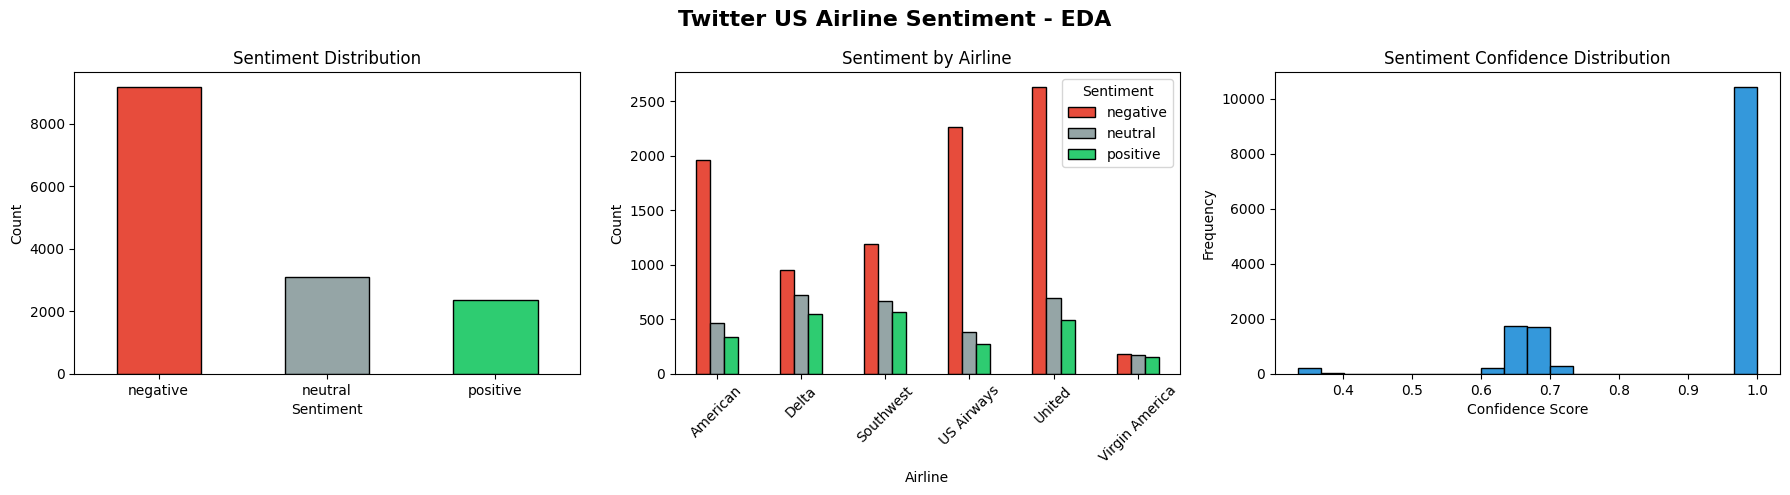

✅ EDA plot saved


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Twitter US Airline Sentiment - EDA', fontsize=16, fontweight='bold')

# Plot 1 - Sentiment Distribution
colors = ['#e74c3c', '#95a5a6', '#2ecc71']
df['airline_sentiment'].value_counts().plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='black'
)
axes[0].set_title('Sentiment Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Plot 2 - Sentiment by Airline
sentiment_airline = df.groupby(['airline', 'airline_sentiment']).size().unstack()
sentiment_airline.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Sentiment by Airline')
axes[1].set_xlabel('Airline')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Sentiment')

# Plot 3 - Confidence Score Distribution
df['airline_sentiment_confidence'].plot(
    kind='hist', ax=axes[2], bins=20, color='#3498db', edgecolor='black'
)
axes[2].set_title('Sentiment Confidence Distribution')
axes[2].set_xlabel('Confidence Score')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../model/artifacts/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plot saved")

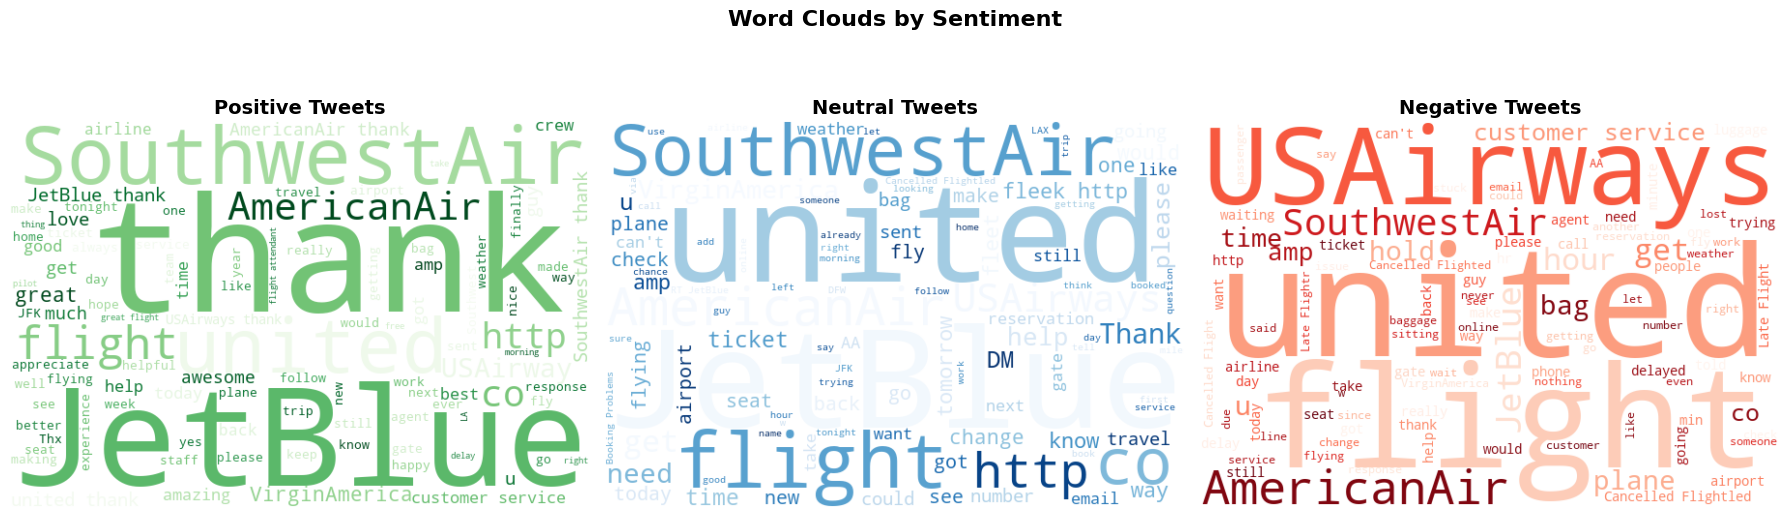

✅ WordCloud saved


In [5]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sentiments = ['positive', 'neutral', 'negative']
colors_map = ['Greens', 'Blues', 'Reds']

for i, sentiment in enumerate(sentiments):
    text = ' '.join(df[df['airline_sentiment'] == sentiment]['text'].astype(str))
    wordcloud = WordCloud(
        width=600, height=400,
        background_color='white',
        stopwords=stop_words,
        colormap=colors_map[i],
        max_words=100
    ).generate(text)
    
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'{sentiment.capitalize()} Tweets', fontsize=14, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Word Clouds by Sentiment', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../model/artifacts/wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ WordCloud saved")

In [6]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()                          # lowercase
    text = re.sub(r'@\w+', '', text)                  # remove @mentions
    text = re.sub(r'http\S+|www\S+', '', text)        # remove URLs
    text = re.sub(r'#\w+', '', text)                  # remove hashtags
    text = re.sub(r'[^a-z\s]', '', text)              # remove special chars
    text = ' '.join(w for w in text.split() if w not in stop_words)  # remove stopwords
    text = text.strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

print("✅ Text cleaned!")
print("\nOriginal:", df['text'].iloc[0])
print("\nCleaned: ", df['clean_text'].iloc[0])

✅ Text cleaned!

Original: @VirginAmerica What @dhepburn said.

Cleaned:  said


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode sentiment labels
le = LabelEncoder()
df['sentiment_label'] = le.fit_transform(df['airline_sentiment'])

# negative=0, neutral=1, positive=2
print("Label Encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

# Split data
X = df['clean_text']
y = df['sentiment_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Data Split:")
print(f"  Training samples: {len(X_train)}")
print(f"  Testing samples:  {len(X_test)}")

Label Encoding:
  negative → 0
  neutral → 1
  positive → 2

✅ Data Split:
  Training samples: 11712
  Testing samples:  2928


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("✅ TF-IDF vectorization done")
print(f"   Vocabulary size: {len(tfidf.vocabulary_)}")

# Train models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVM': LinearSVC(max_iter=1000, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'accuracy': acc, 'predictions': y_pred}
    print(f"\n📊 {name}")
    print(f"   Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

✅ TF-IDF vectorization done
   Vocabulary size: 10000

📊 Logistic Regression
   Accuracy: 0.7756
              precision    recall  f1-score   support

    negative       0.79      0.95      0.86      1835
     neutral       0.65      0.44      0.53       620
    positive       0.83      0.55      0.66       473

    accuracy                           0.78      2928
   macro avg       0.76      0.65      0.68      2928
weighted avg       0.77      0.78      0.76      2928


📊 Linear SVM
   Accuracy: 0.7783
              precision    recall  f1-score   support

    negative       0.83      0.90      0.86      1835
     neutral       0.59      0.54      0.57       620
    positive       0.78      0.62      0.69       473

    accuracy                           0.78      2928
   macro avg       0.73      0.69      0.71      2928
weighted avg       0.77      0.78      0.77      2928



In [9]:
import joblib
import os

# Best model is Linear SVM
best_model = results['Linear SVM']['model']

# Save model, vectorizer and label encoder
os.makedirs('../model/artifacts', exist_ok=True)

joblib.dump(best_model, '../model/artifacts/sentiment_model.pkl')
joblib.dump(tfidf, '../model/artifacts/tfidf_vectorizer.pkl')
joblib.dump(le, '../model/artifacts/label_encoder.pkl')

print("✅ Artifacts saved:")
print("   - sentiment_model.pkl")
print("   - tfidf_vectorizer.pkl")
print("   - label_encoder.pkl")

✅ Artifacts saved:
   - sentiment_model.pkl
   - tfidf_vectorizer.pkl
   - label_encoder.pkl


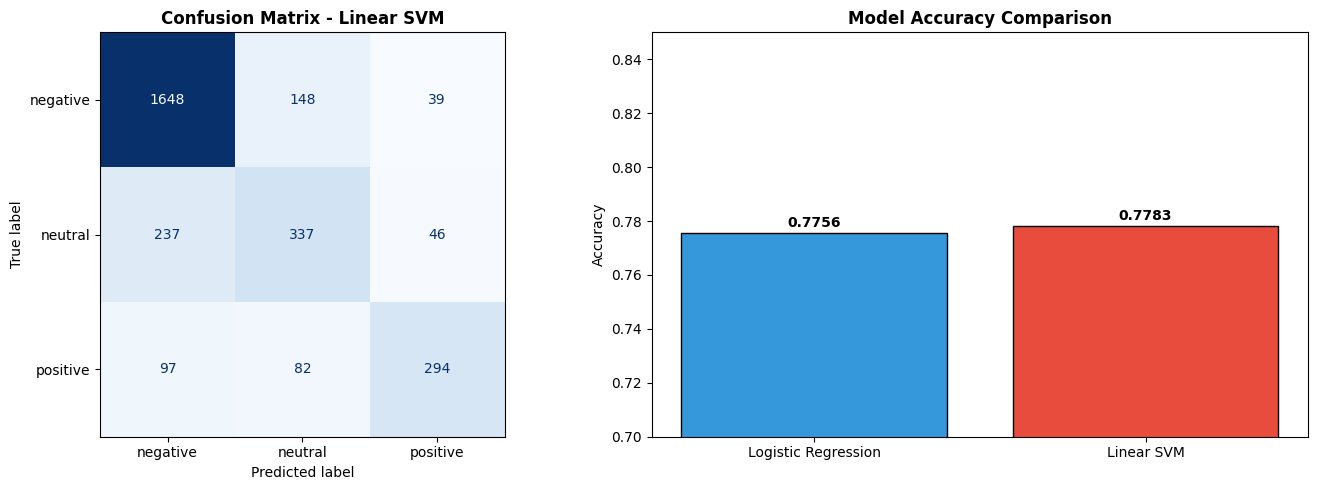

✅ Model comparison plot saved


In [10]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, results['Linear SVM']['predictions'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix - Linear SVM', fontweight='bold')

# Model Comparison Bar Chart
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]

axes[1].bar(model_names, accuracies, color=['#3498db', '#e74c3c'], edgecolor='black')
axes[1].set_title('Model Accuracy Comparison', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.7, 0.85)
for i, v in enumerate(accuracies):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../model/artifacts/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model comparison plot saved")